# Practice 02 — Funnel Analysis
**Context:** The growth team needs a funnel report to identify where users drop off in the card application flow.

You need to build the full drop-off analysis — from raw data to a presentation-ready figure.

---
**Reference notebooks:** `course/03_chart_types.ipynb`, `course/05_annotations.ipynb`

In [52]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])

STEPS = [
    'visita_landing', 'inicio_solicitud', 'datos_personales', 'otp',
    'datos_financieros', 'carga_documentos', 'evaluacion_crediticia',
    'aprobacion', 'firma_digital', 'activacion_tarjeta'
]
LABELS = [
    'Landing', 'Start', 'Personal Data', 'OTP',
    'Financial Data', 'Documents', 'Credit Eval',
    'Approval', 'Signature', 'Activation'
]

totals = df[STEPS].sum()
print(totals)

visita_landing           284774
inicio_solicitud         101667
datos_personales          76089
otp                       52498
datos_financieros         42539
carga_documentos          25106
evaluacion_crediticia     22375
aprobacion                11645
firma_digital              9338
activacion_tarjeta         6337
dtype: int64


---
## Exercise 1 — Compute drop-off rates

Calculate the % drop from each step to the next.

Expected output: a list or Series with 9 values (one per transition), like:
```
Start:         64.3%
Personal Data: 25.2%
...
```

💡 Hint: `drop = (prev - current) / prev * 100`

['Start', 'Personal Data', 'OTP', 'Financial Data', 'Documents', 'Credit Eval', 'Approval', 'Signature', 'Activation']


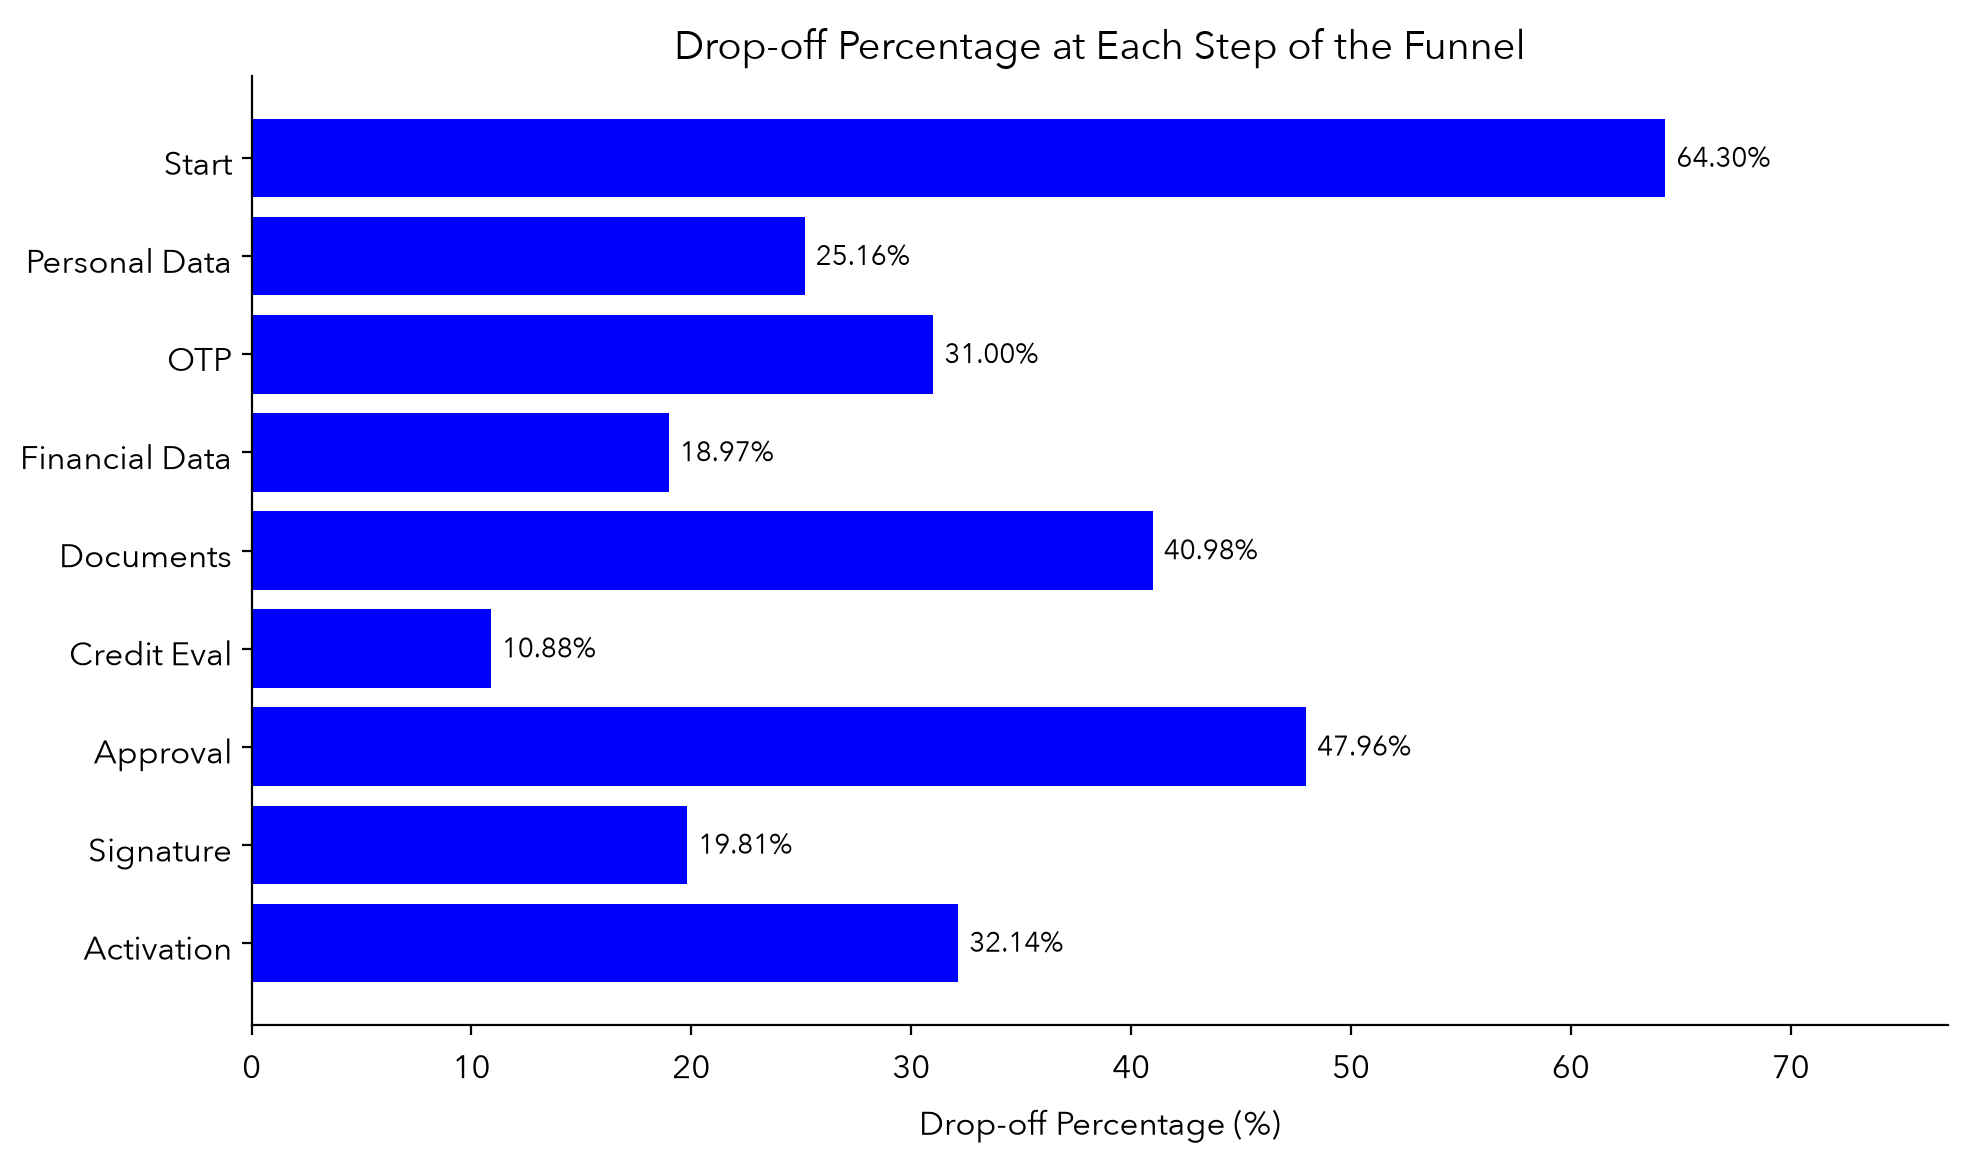

In [53]:
# Your code here

plt.rcParams.update({'font.family': 'Avenir Next', 'font.size': 12})  # Set default font family and size

# drops = ?
current_steps = STEPS[1:]
prev_steps = STEPS[:-1]

current_labels = LABELS[1:]
print(current_labels)

drop = [(totals[prev_steps[i]] - totals[current_steps[i]]) / totals[prev_steps[i]] * 100 for i in range(len(current_steps))]

fig, ax = plt.subplots(figsize=(10, 6),dpi=200)

bars = ax.barh(current_labels, drop, color='blue')
for bar, val in zip(bars, drop):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.2f}%', va='center', fontsize=10)

ax.set_xlabel('Drop-off Percentage (%)')
ax.set_title('Drop-off Percentage at Each Step of the Funnel')
ax.set_xlim(0, max(drop) * 1.2)  # Set x-axis limit for better visualization
ax.invert_yaxis()  # Invert y-axis to show drop-offs from left to right
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


['Start', 'Personal Data', 'OTP', 'Financial Data', 'Documents', 'Credit Eval', 'Approval', 'Signature', 'Activation']


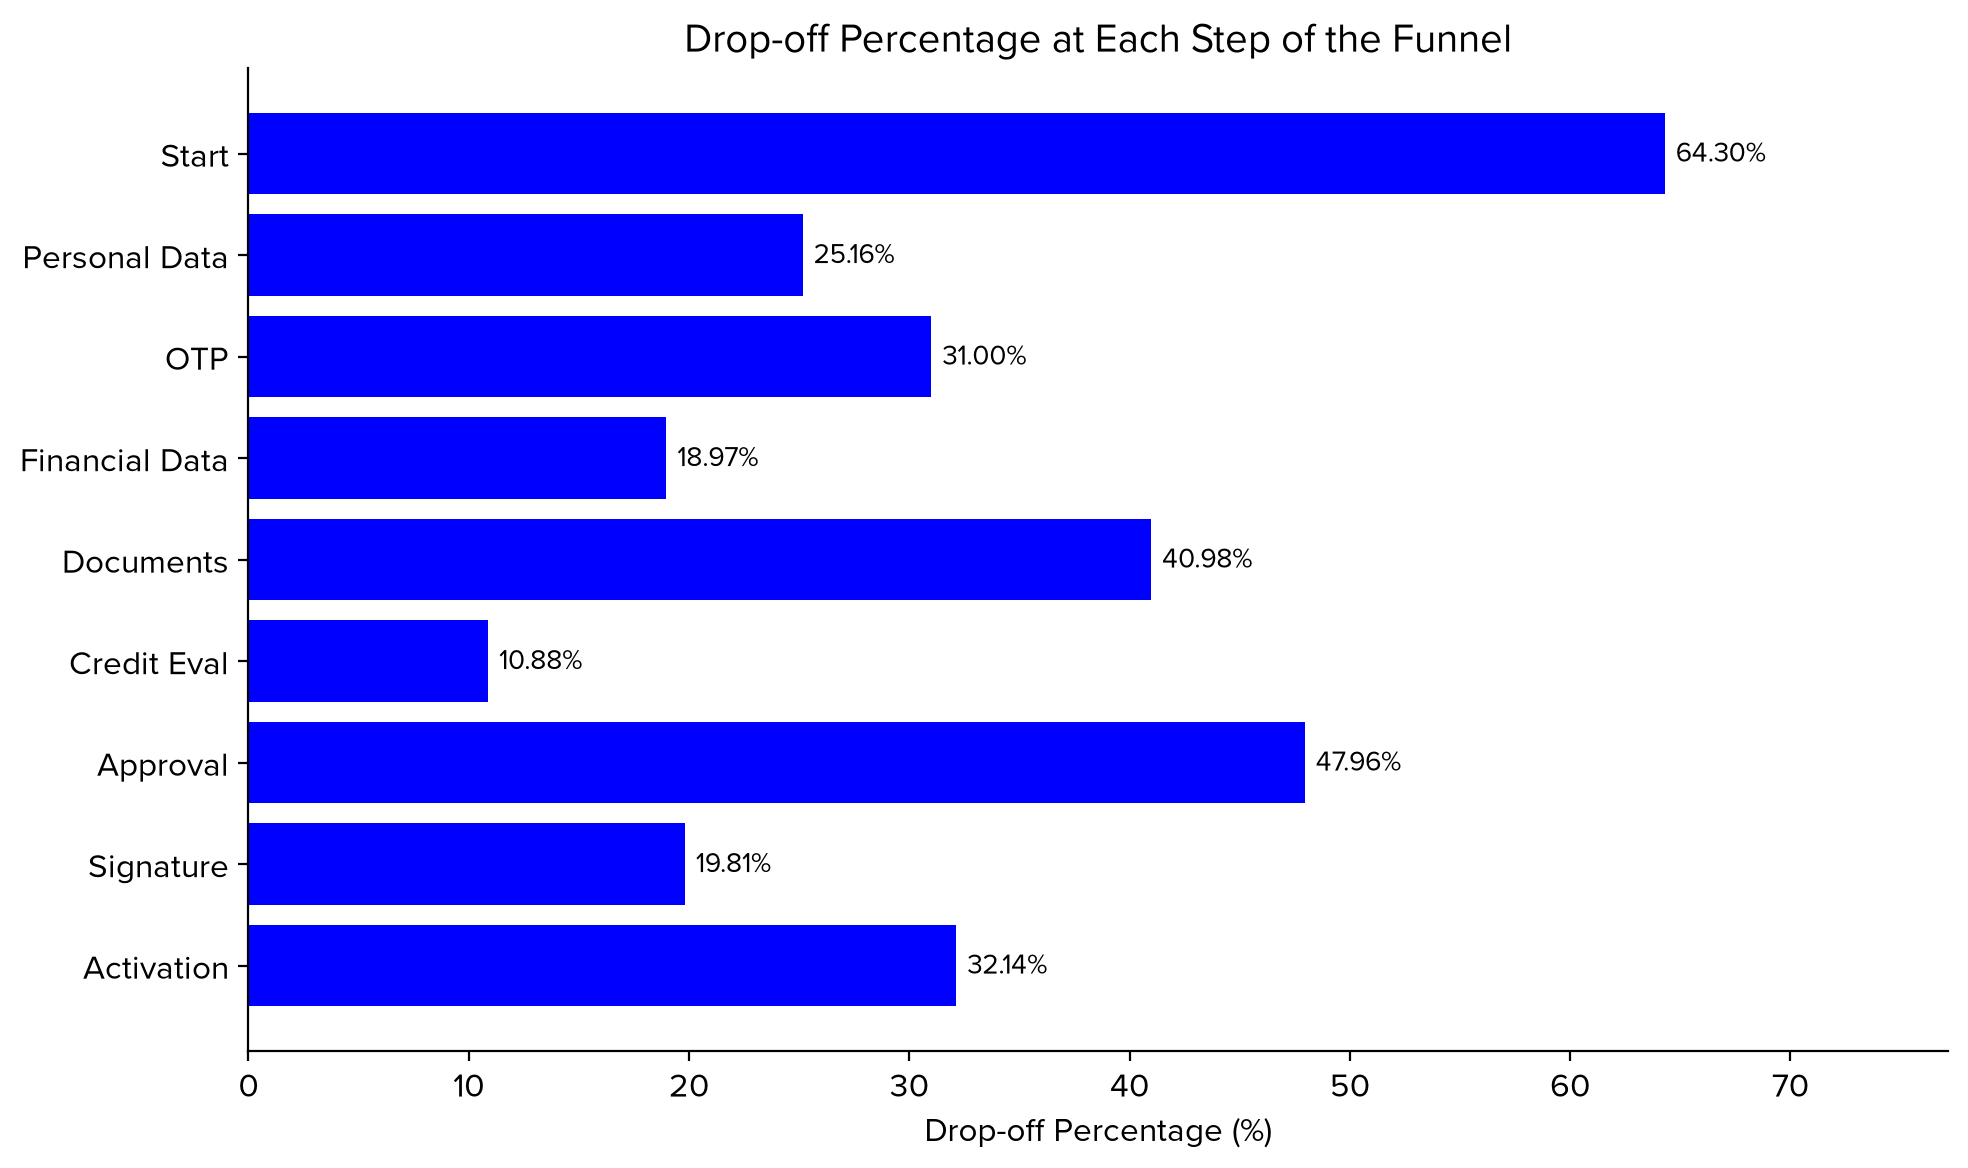

In [54]:
# Your code here

plt.rcParams.update({'font.family': 'Proxima Nova', 'font.size': 12})  # Set default font family and size

# drops = ?
current_steps = STEPS[1:]
prev_steps = STEPS[:-1]

current_labels = LABELS[1:]
print(current_labels)

drop = [(totals[prev_steps[i]] - totals[current_steps[i]]) / totals[prev_steps[i]] * 100 for i in range(len(current_steps))]

fig, ax = plt.subplots(figsize=(10, 6),dpi=200)

bars = ax.barh(current_labels, drop,color='blue')
for bar, val in zip(bars, drop):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.2f}%', va='center', fontsize=10)

ax.set_xlabel('Drop-off Percentage (%)')
ax.set_title('Drop-off Percentage at Each Step of the Funnel')
ax.set_xlim(0, max(drop) * 1.2)  # Set x-axis limit for better visualization
ax.invert_yaxis()  # Invert y-axis to show drop-offs from left to right
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


---
## Exercise 2 — Horizontal bar chart of drop-off rates

Build a horizontal bar chart showing the drop-off at each step.

Requirements:
- Color bars by severity: red if drop > 30%, orange if > 15%, green otherwise
- Show the % value at the end of each bar
- First step at the top (`ax.invert_yaxis()`)
- Clean styling

💡 Hint: `ax.barh(labels, values, color=colors)`

['Start', 'Personal Data', 'OTP', 'Financial Data', 'Documents', 'Credit Eval', 'Approval', 'Signature', 'Activation']


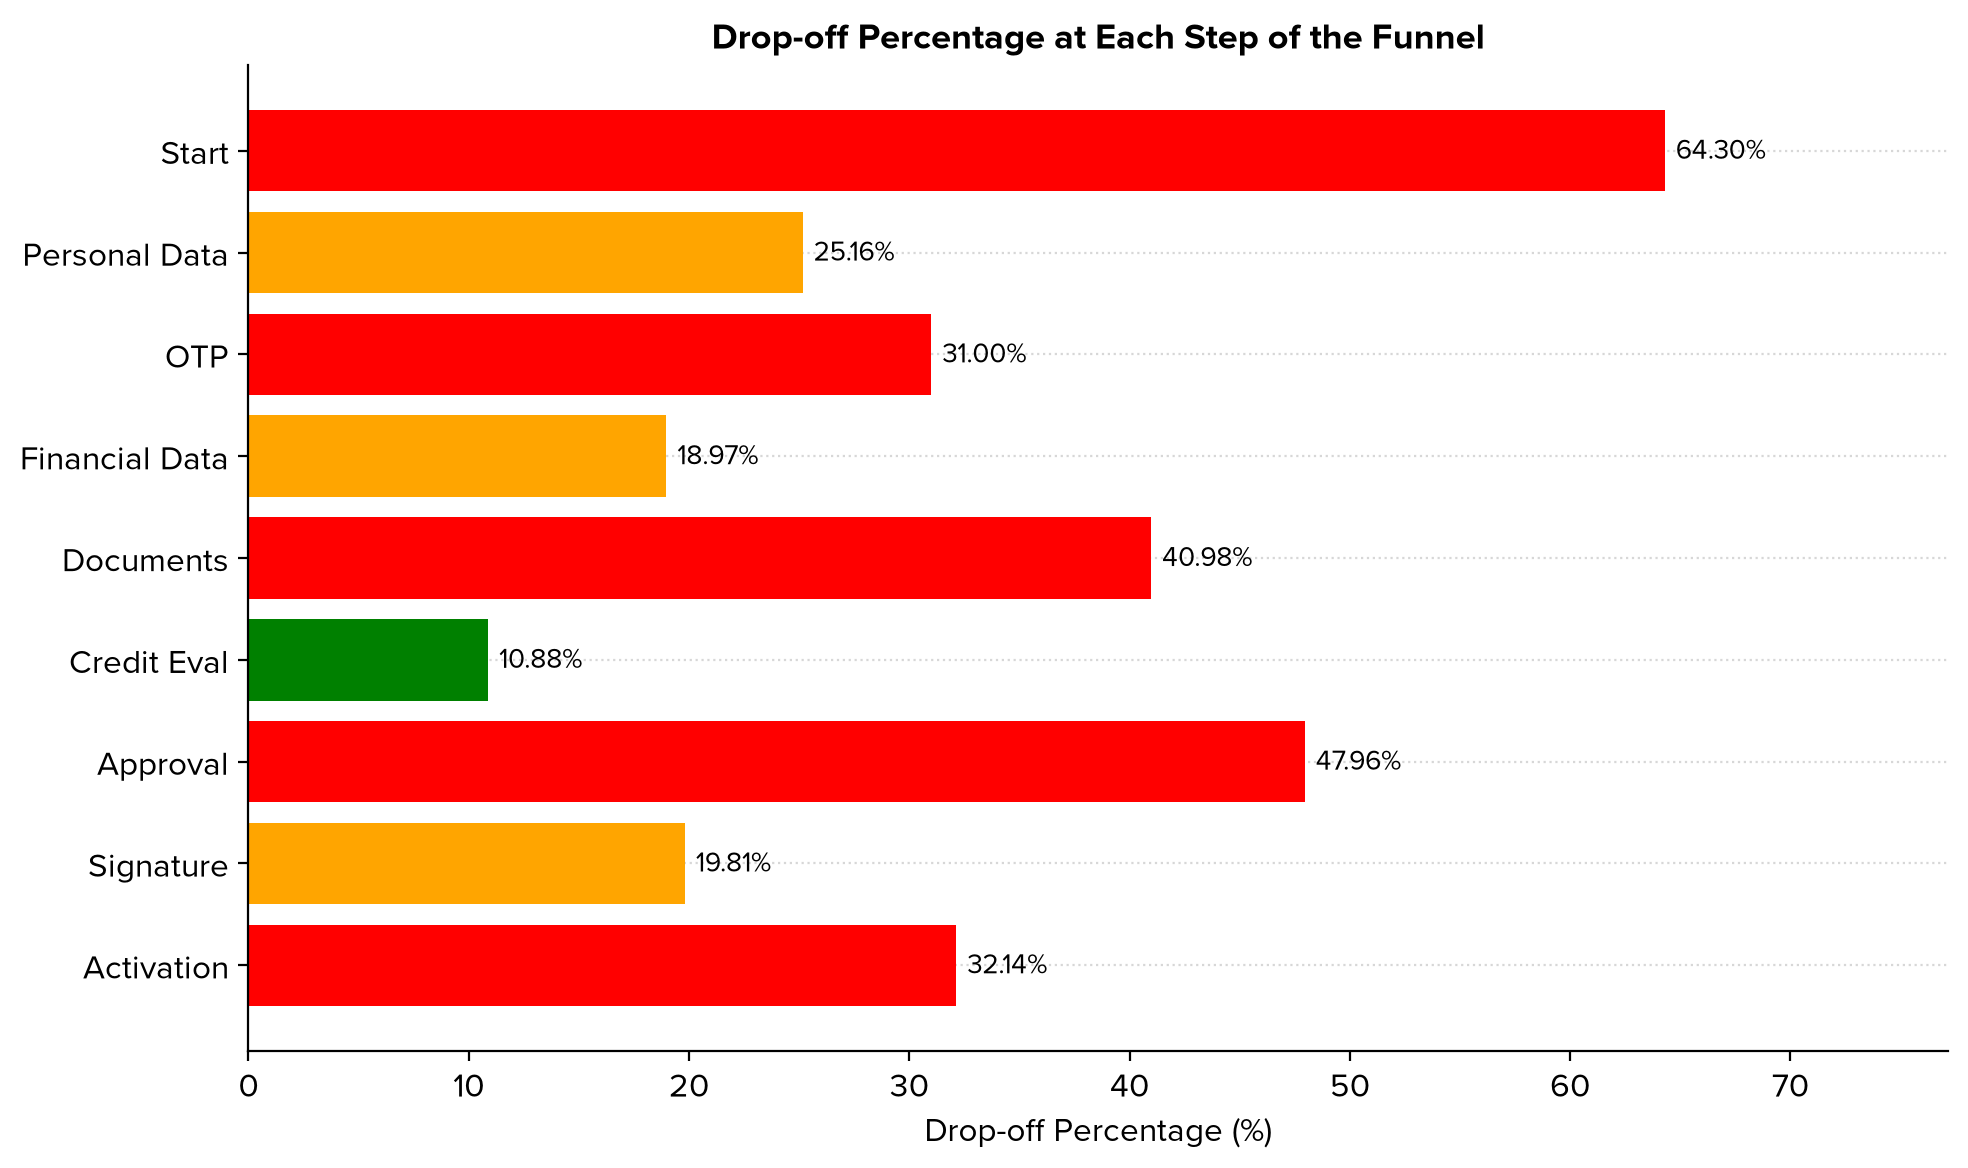

In [55]:
# Your code here
# Your code here

plt.rcParams.update({'font.family': 'Proxima Nova', 'font.size': 12})  # Set default font family and size

# drops = ?
current_steps = STEPS[1:]
prev_steps = STEPS[:-1]

current_labels = LABELS[1:]
print(current_labels)

drop = [(totals[prev_steps[i]] - totals[current_steps[i]]) / totals[prev_steps[i]] * 100 for i in range(len(current_steps))]

fig, ax = plt.subplots(figsize=(10, 6),dpi=200)

colors_format = ['red' if d > 30 else 'orange' if d > 15 else 'green' for d in drop]

bars = ax.barh(current_labels, drop,color=colors_format)
for bar, val in zip(bars, drop):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.2f}%', va='center', fontsize=10)

ax.set_xlabel('Drop-off Percentage (%)')
ax.set_title('Drop-off Percentage at Each Step of the Funnel', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(drop) * 1.2)  # Set x-axis limit for better visualization
ax.invert_yaxis()  # Invert y-axis to show drop-offs from left to right
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.5)  # Add grid lines for x-axis
ax.set_axisbelow(True)  # Ensure grid lines are below the bars

plt.tight_layout()
plt.show()


---
## Exercise 3 — Compare drop-off: organic vs paid

Filter the data for organic and paid channels separately, compute drop-off for each, and plot them side by side.

Requirements:
- Two subplots: `plt.subplots(1, 2)`
- Same x-axis scale for fair comparison (`sharex=True`)
- Title per subplot indicating the channel
- Figure title: "Drop-off Comparison: Organic vs Paid"

💡 Hint: `df[df['channel'] == 'organic'][STEPS].sum()`

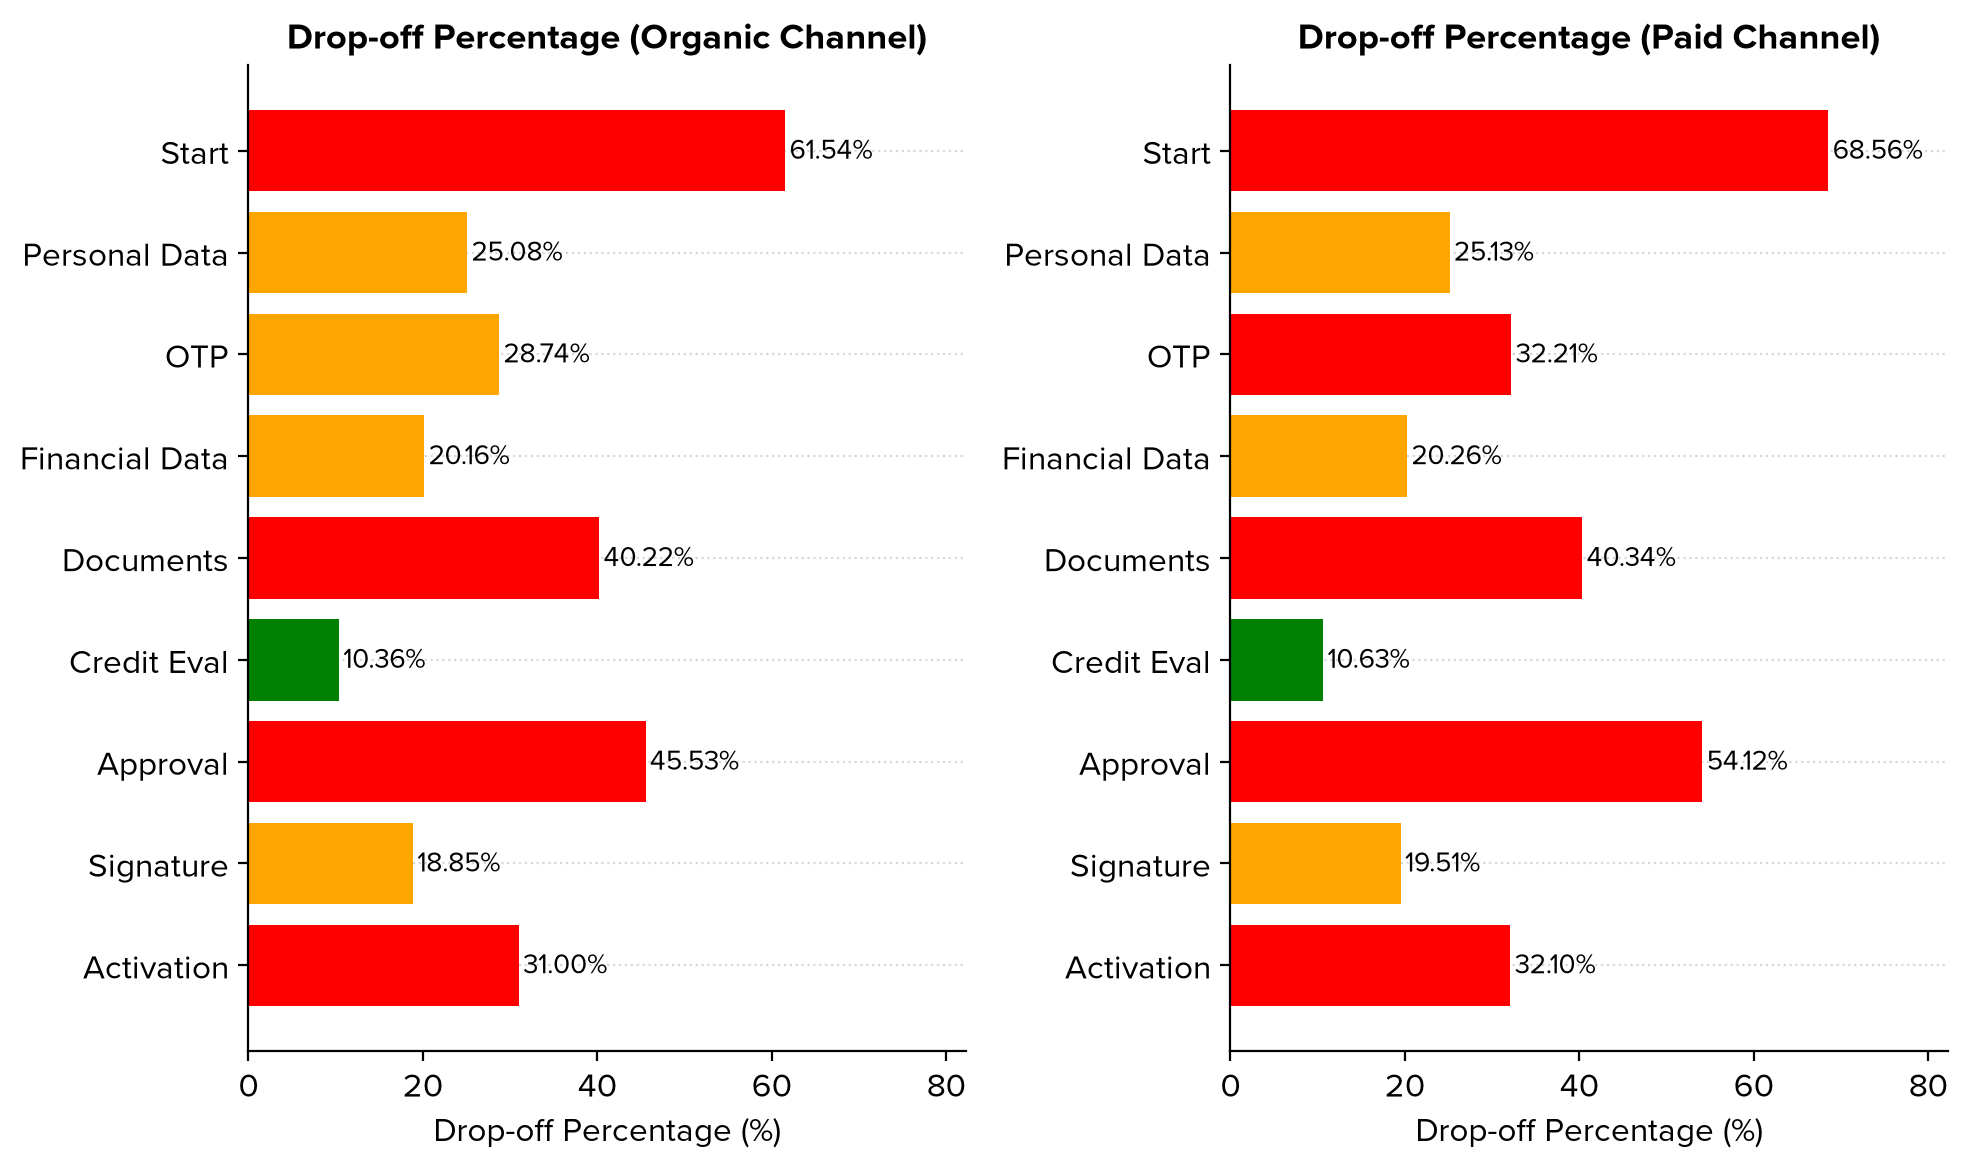

In [56]:
# Your code here
fig, axes = plt.subplots(1,2,figsize=(10, 6),dpi=200, sharex=True)

channel = ['organic', 'paid']

for i, ch in enumerate(channel):
    channel_data = df[df['channel'] == ch]
    totals_channel = channel_data[STEPS].sum()
    
    drop_channel = [(totals_channel[prev_steps[j]] - totals_channel[current_steps[j]]) / totals_channel[prev_steps[j]] * 100 for j in range(len(current_steps))]
    
    colors_format = ['red' if d > 30 else 'orange' if d > 15 else 'green' for d in drop_channel]
    
    bars = axes[i].barh(current_labels, drop_channel, color=colors_format)
    for bar, val in zip(bars, drop_channel):
        axes[i].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.2f}%', va='center', fontsize=10)
    
    axes[i].set_xlabel('Drop-off Percentage (%)')
    axes[i].set_title(f'Drop-off Percentage ({ch.capitalize()} Channel)', fontsize=13, fontweight='bold')
    axes[i].set_xlim(0, max(drop_channel) * 1.2)  # Set x-axis limit for better visualization
    axes[i].invert_yaxis()  # Invert y-axis to show drop-offs from left to right
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].grid(axis='y', linestyle=':', alpha=0.5)  # Add grid lines for x-axis
    axes[i].set_axisbelow(True)  # Ensure grid lines are below the bars

plt.tight_layout()
plt.show()

---
## Exercise 4 — Annotate the biggest problem

Take your chart from Exercise 2 and add:
- An arrow + text annotation on the step with the highest drop-off
- A vertical reference line at 30% (your "alert threshold")
- A shaded region from 30% to 70% in light red to mark the "danger zone"

💡 Hint: `ax.axvline(x=30)` and `ax.axvspan(30, 70, alpha=0.08, color='red')`

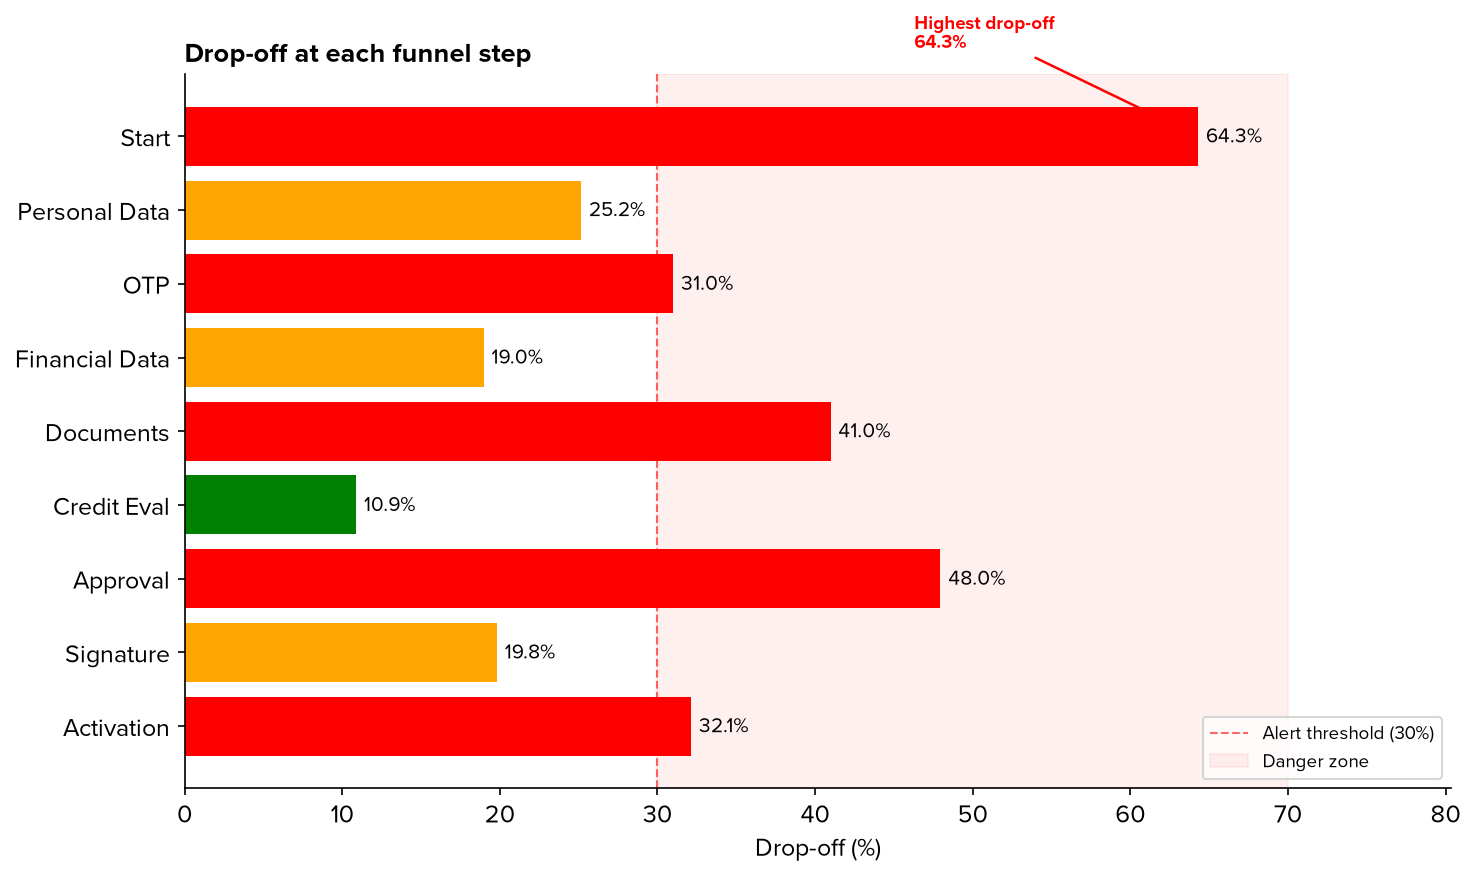

In [57]:
prev_steps    = STEPS[:-1]
current_steps = STEPS[1:]
current_labels = LABELS[1:]

drop = [(totals[prev_steps[i]] - totals[current_steps[i]]) / totals[prev_steps[i]] * 100
        for i in range(len(current_steps))]

colors_fmt = ['red' if d > 30 else 'orange' if d > 15 else 'green' for d in drop]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

bars = ax.barh(current_labels, drop, color=colors_fmt)
for bar, val in zip(bars, drop):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10)

# --- Arrow annotation on worst drop-off ---
max_idx = drop.index(max(drop))
ax.annotate(
    f'Highest drop-off\n{drop[max_idx]:.1f}%',
    xy=(drop[max_idx], max_idx),
    xytext=(drop[max_idx] - 18, max_idx - 1.2),
    fontsize=9, color='red', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='red', lw=1.2),
)

# --- Reference line and danger zone ---
ax.axvline(x=30, color='red', linewidth=1, linestyle='--', alpha=0.6, label='Alert threshold (30%)')
ax.axvspan(30, 70, alpha=0.06, color='red', label='Danger zone')

ax.set_xlabel('Drop-off (%)')
ax.set_title('Drop-off at each funnel step', fontsize=13, fontweight='bold', loc='left')
ax.set_xlim(0, max(drop) * 1.25)
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

---
## Bonus — Full report figure

Combine everything into one figure using `GridSpec`:
- Top panel (wide): overall funnel volumes as a bar chart
- Bottom left: drop-off rates with color coding
- Bottom right: organic vs paid CVR comparison

Save it as `data/practice_02_funnel_report.pdf`

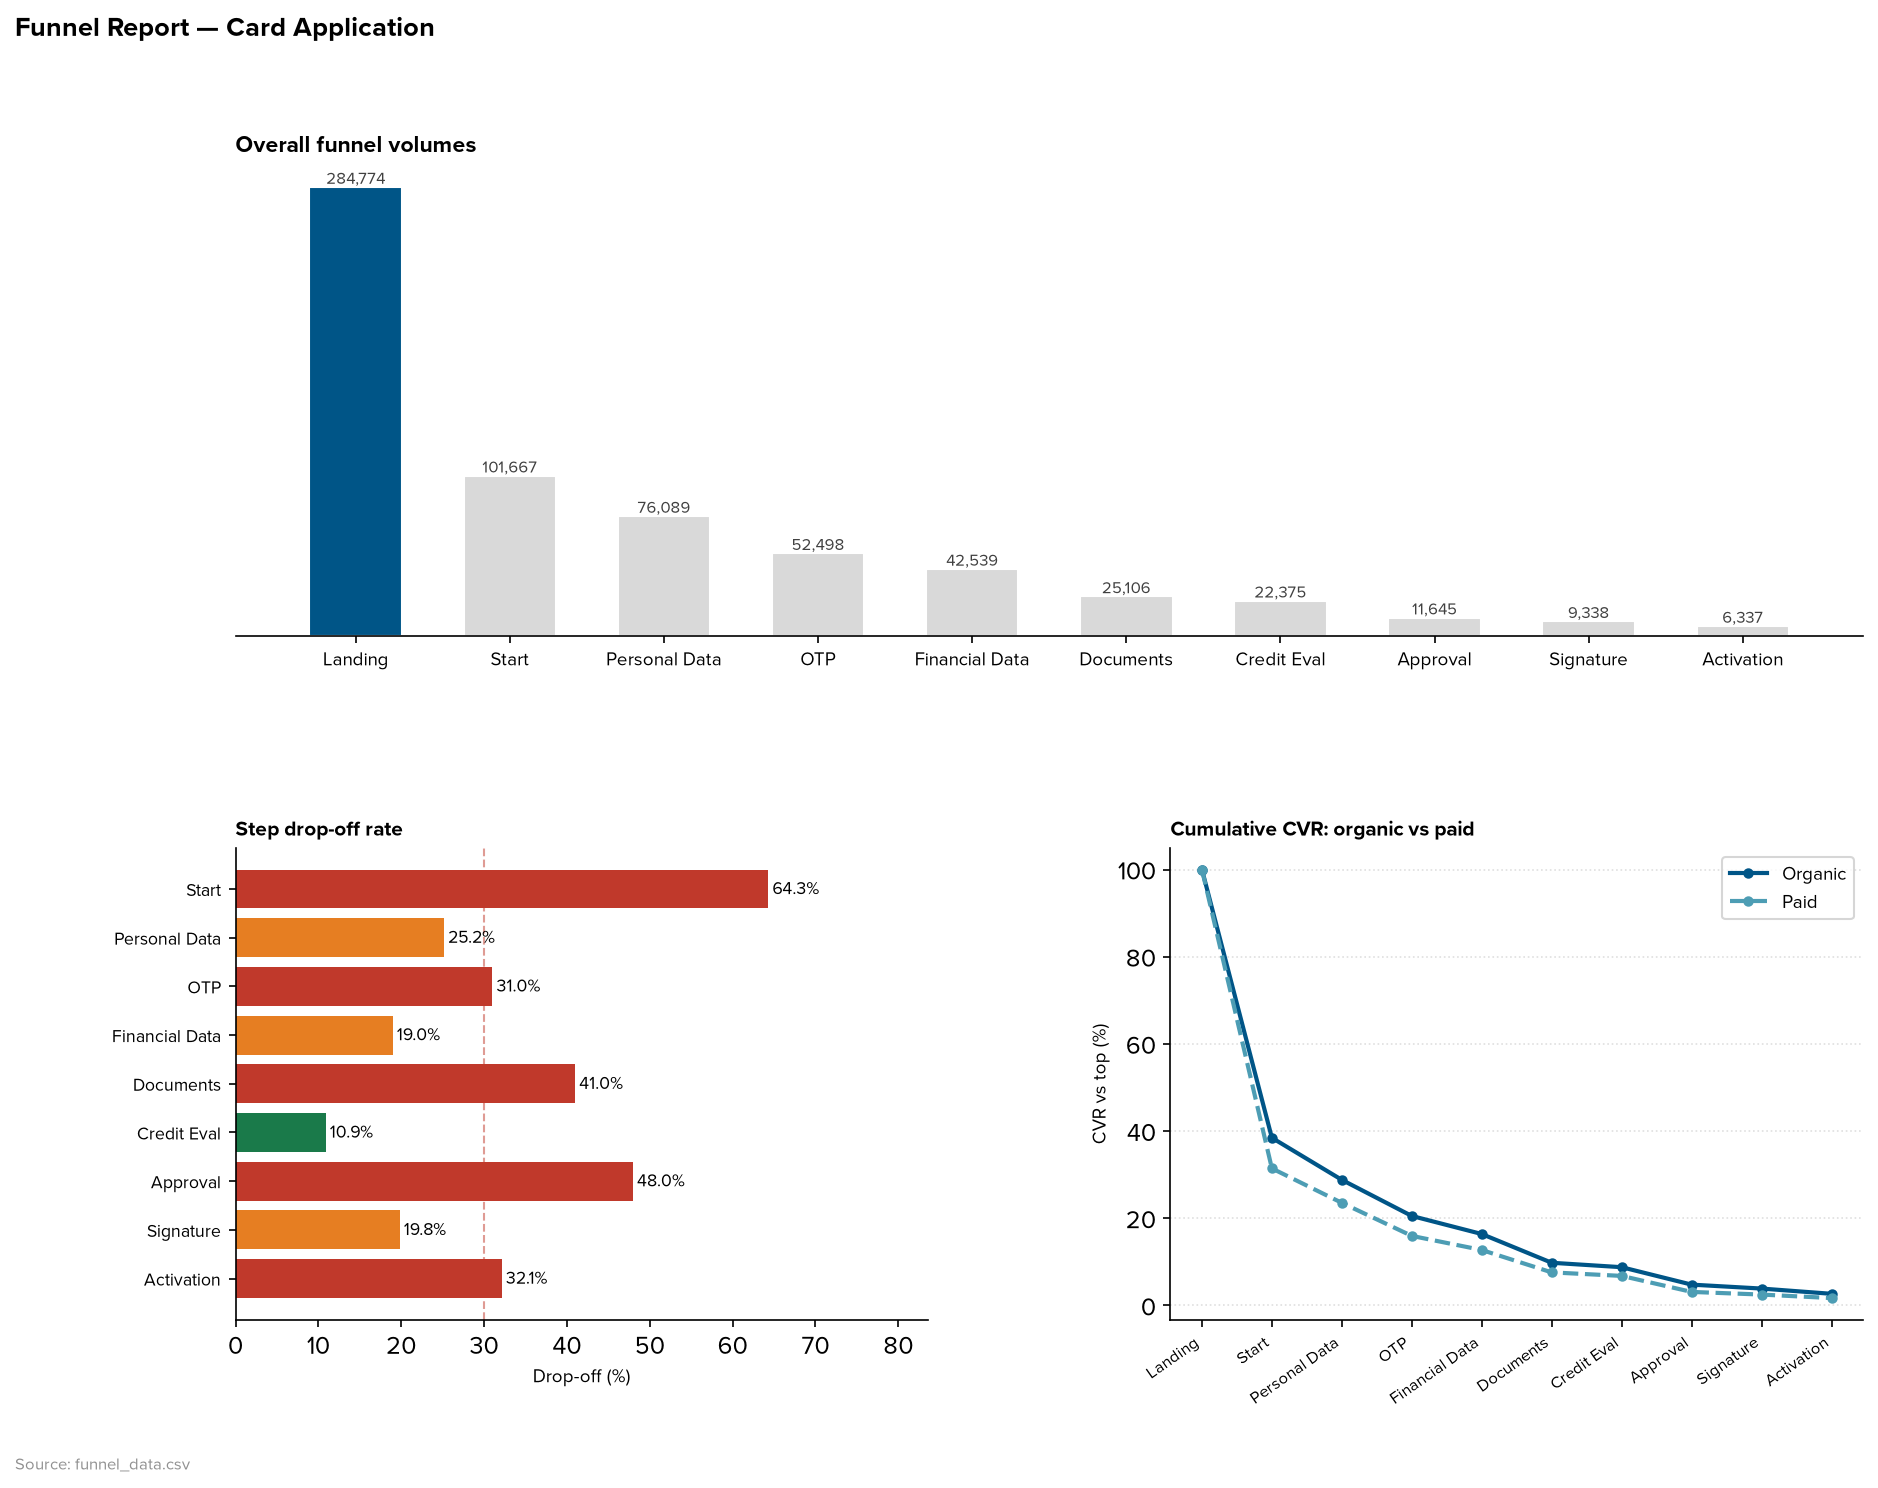

Saved → data/practice_02_funnel_report.pdf


In [58]:
import matplotlib.gridspec as gridspec

# ── helpers ────────────────────────────────────────────────────────────────
def compute_drop(totals_series):
    return [(totals_series[prev_steps[i]] - totals_series[current_steps[i]])
            / totals_series[prev_steps[i]] * 100
            for i in range(len(current_steps))]

def compute_cvr(totals_series):
    """Cumulative CVR at each step relative to top of funnel."""
    top = totals_series[STEPS[0]]
    return [totals_series[s] / top * 100 for s in STEPS]

# ── data ───────────────────────────────────────────────────────────────────
totals_organic = df[df['channel'] == 'organic'][STEPS].sum()
totals_paid    = df[df['channel'] == 'paid'][STEPS].sum()

drop_all     = compute_drop(totals)
drop_organic = compute_drop(totals_organic)
drop_paid    = compute_drop(totals_paid)

cvr_organic  = compute_cvr(totals_organic)
cvr_paid     = compute_cvr(totals_paid)

colors_fmt = ['#c0392b' if d > 30 else '#e67e22' if d > 15 else '#1a7a4a' for d in drop_all]

# ── layout ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10), dpi=150)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax_top   = fig.add_subplot(gs[0, :])   # top: full width
ax_bot_l = fig.add_subplot(gs[1, 0])   # bottom left
ax_bot_r = fig.add_subplot(gs[1, 1])   # bottom right

# ── Top: funnel volumes ─────────────────────────────────────────────────────
bar_colors = ['#005587' if s == 'visita_landing' else '#d9d9d9' for s in STEPS]
ax_top.bar(LABELS, totals.values, color=bar_colors, edgecolor='white', width=0.6)
for x, val in enumerate(totals.values):
    ax_top.text(x, val + 2000, f'{val:,.0f}', ha='center', fontsize=8, color='#404040')
ax_top.set_title('Overall funnel volumes', fontsize=11, fontweight='bold', loc='left')
ax_top.spines[['top', 'right', 'left']].set_visible(False)
ax_top.yaxis.set_visible(False)
ax_top.tick_params(axis='x', labelsize=9)

# ── Bottom left: drop-off ───────────────────────────────────────────────────
bars = ax_bot_l.barh(current_labels, drop_all, color=colors_fmt)
for bar, val in zip(bars, drop_all):
    ax_bot_l.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                  f'{val:.1f}%', va='center', fontsize=8.5)
ax_bot_l.axvline(30, color='#c0392b', lw=1, linestyle='--', alpha=0.5)
ax_bot_l.set_title('Step drop-off rate', fontsize=10, fontweight='bold', loc='left')
ax_bot_l.set_xlim(0, max(drop_all) * 1.3)
ax_bot_l.invert_yaxis()
ax_bot_l.spines[['top', 'right']].set_visible(False)
ax_bot_l.tick_params(axis='y', labelsize=8.5)
ax_bot_l.set_xlabel('Drop-off (%)', fontsize=9)

# ── Bottom right: organic vs paid cumulative CVR ────────────────────────────
x = range(len(LABELS))
ax_bot_r.plot(x, cvr_organic, color='#005587', linewidth=2, marker='o', markersize=4, label='Organic')
ax_bot_r.plot(x, cvr_paid,    color='#4d9db4', linewidth=2, marker='o', markersize=4, label='Paid', linestyle='--')
ax_bot_r.set_title('Cumulative CVR: organic vs paid', fontsize=10, fontweight='bold', loc='left')
ax_bot_r.set_xticks(list(x))
ax_bot_r.set_xticklabels(LABELS, rotation=35, ha='right', fontsize=8)
ax_bot_r.set_ylabel('CVR vs top (%)', fontsize=9)
ax_bot_r.spines[['top', 'right']].set_visible(False)
ax_bot_r.legend(fontsize=9)
ax_bot_r.grid(axis='y', linestyle=':', alpha=0.4)

fig.suptitle('Funnel Report — Card Application', fontsize=13, fontweight='bold', x=0.02, ha='left', y=0.98)
fig.text(0.02, 0.01, 'Source: funnel_data.csv', fontsize=8, color='#919191')

plt.savefig('data/practice_02_funnel_report.pdf', bbox_inches='tight')
plt.show()
print('Saved → data/practice_02_funnel_report.pdf')